##

# CHAZ vectorized checks

Recreating several of the figures from: 
- Lee et al. 2018 
    - C.-Y. Lee, M.K. Tippett, A.H. Sobel, and S.J. Camargo, 2018. An environmentally forced tropical cyclone hazard model. Journal of Advances in Modeling Earth Systems, 10, 233-241, doi: 10.1002/2017MS001186.


- Lee et al. 2025

to figure out whether or not the sped-up chaz is comparable (or improved?) (((or worse???)))



In [1]:
import numpy as np
import pandas as pd
#import cProfile
#import time

import xarray as xr

import calendar
from datetime import datetime

import netCDF4 as nc

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import cartopy as cart
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy import stats
from scipy.stats import gaussian_kde


import Namelist as gv

from tools.util import getbasinMap, defineBasin


# for making sure we're using the most recent intensity file 
import os
import time

# import netCDF4 as nc
import glob

### TEMPORARY (hopefully) code snippet so that the HTML view of datasets/dataarrays is viewable in darkmode on jupyter lab/VS code
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

### Import updated and original data

In [2]:
### need to update to support multiple track realizations for updated data 


## ORIGINAL
## n.b. July 22nd figures in slide dek are a mix of ens000 and ens059, but results are largely similar
ds_old_tmp = xr.open_dataset('/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens000_pre.nc').load()
mask = (ds_old_tmp['year'] >= 2000) & (ds_old_tmp['year'] <= 2009)
ds_old = ds_old_tmp.isel(stormID=mask)


### UPDATED
def preprocess(ds):
    # each file's `year` variable is constant across stormID, so grab the first value
    yr = int(ds['year'].values[0])
    return ds.expand_dims(year_dim=[yr])

## cheeky way to just get 2000-2009 (for now)
filenames = sorted(glob.glob(gv.output_path+'/ERA5_*_ens*.nc'))

ds_new = xr.open_mfdataset(
    filenames,
    preprocess=preprocess,
    combine="nested",
    concat_dim="year_dim",
).load()

In [3]:
filenames

['/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens000.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens001.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens002.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens003.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens004.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens005.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens006.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens007.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens008.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1950_ens009.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1951_ens000.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1951_ens001.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1951_ens002.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1951_ens003.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1951_ens004.nc',
 '/data0/miriamn/CHAZvectorized/output/ERA5_1951_ens005.nc',
 '/data0/miriamn/CHAZvec

### Tracks
- color coded by intensity

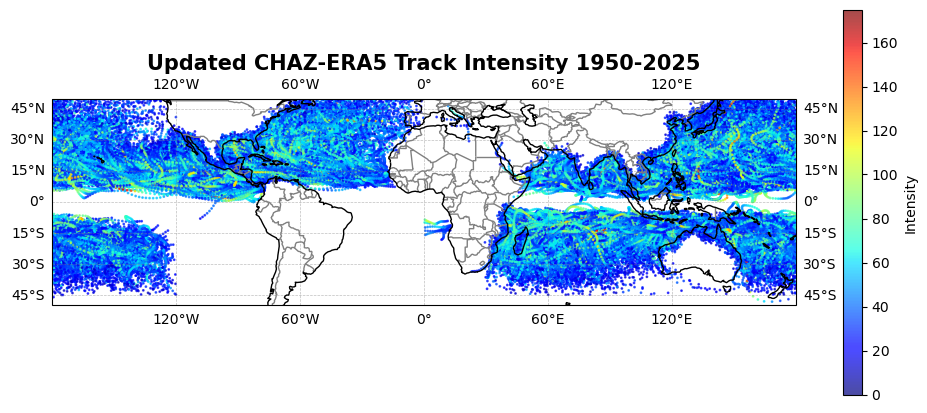

In [4]:
years = [str(year) for year in np.arange(gv.Year1, gv.Year2)]

fig = plt.figure(figsize=(12,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(zorder=100)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
        linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

gl.xlabels_top = False
gl.ylabels_right = False

gl.xlocator = mticker.FixedLocator(range(-180,180,60))
gl.ylocator = mticker.FixedLocator(range(-90, 90,15))

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

ax.add_feature(cart.feature.BORDERS, color = 'gray')
ax.set_extent([-180,180,-50,50])

# n_bins = 8  
# cmap = plt.get_cmap('jet', n_bins) 

iN = 0
for iy in range(len(years)):
        filename = gv.output_path + '/ERA5_'+years[iy]+'_ens000.nc'
        data = nc.Dataset(filename)
        lon = data['longitude'][:]
        lat = data['latitude'][:]
        mwspd = data['Mwspd'][:]
        plt.scatter(lon.ravel(), lat.ravel(), s=1, 
                c=mwspd[iN,:,:].ravel(), 
                cmap = 'jet',
                vmin = 0, vmax = 175, 
                alpha = 0.7)

plt.colorbar(label='Intensity')
plt.title(f'Updated CHAZ-ERA5 Track Intensity {gv.Year1}-{gv.Year2}', fontweight = 'bold', fontsize = 15)
plt.savefig(f'figs/CHAZ_storm_tracks_ERA5_{gv.Year1}-{gv.Year2}.png') 

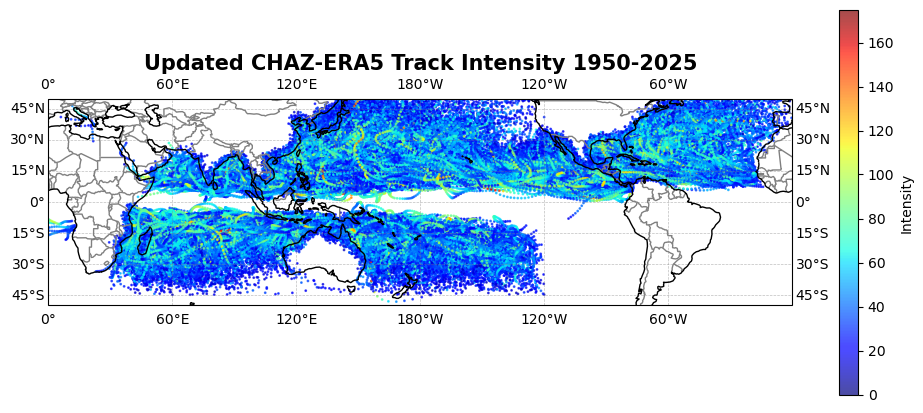

In [5]:
years = [str(year) for year in np.arange(gv.Year1, gv.Year2)]

# Pacific-centered projection
proj = ccrs.PlateCarree(central_longitude=180)
data_crs = ccrs.PlateCarree()  # the CRS your actual lon/lat data is stored in

fig = plt.figure(figsize=(12, 5))
ax = plt.axes(projection=proj)
ax.coastlines(zorder=100)

gl = ax.gridlines(crs=data_crs, draw_labels=True,
        linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

gl.xlabels_top = False
gl.ylabels_right = False

gl.xlocator = mticker.FixedLocator(range(-180, 180, 60))
gl.ylocator = mticker.FixedLocator(range(-90, 90, 15))

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

ax.add_feature(cart.feature.BORDERS, color='gray')

# set_extent still takes lon/lat in the data's own CRS, not the projection's shifted one
ax.set_extent([-180, 180, -50, 50], crs=data_crs)

iN = 0
for iy in range(len(years)):
    filename = gv.output_path+'/ERA5_' + years[iy] + '_ens000.nc'
    ds = xr.open_dataset(filename)

    lon = ds['longitude'].values
    lat = ds['latitude'].values
    mwspd = ds['Mwspd'].values

    sc = ax.scatter(lon.ravel(), lat.ravel(), s=1,
            c=mwspd[iN, :, :].ravel(),
            cmap='jet',
            vmin=0, vmax=175,
            alpha=0.7,
            transform=data_crs)  # tells cartopy these coords are plain lon/lat

    ds.close()

plt.colorbar(sc, label='Intensity')
plt.title(f'Updated CHAZ-ERA5 Track Intensity {gv.Year1}-{gv.Year2}', fontweight='bold', fontsize=15)
plt.savefig(f'figs/CHAZ_storm_tracks_ERA5_{gv.Year1}-{gv.Year2}.png')

In [6]:
def plot_colorline(x,y,z,bins,maxint):
    """
    function for plot track spaghetti
    need to determine maximum intensity value in all storm tracks beforehand to set colormap
    bins are the number of colorbins desired
    """

    data_crs = ccrs.PlateCarree()
    #creating bins of colorvalues
    colorvals = np.linspace(1/bins,1,num=bins)
    #assigning colors based on intensities, the max is 200 (make this more universal)
    nearest = colorvals[abs((z/maxint)[None, :] - colorvals[:, None]).argmin(axis=0)]
    cmap = matplotlib.cm.get_cmap('jet')
    rgba = cmap(nearest)

    #creating bins of zorders
    ordervals = np.linspace(1,bins,num=bins)
    z = ordervals[abs((z/(maxint/bins))[None, :] - ordervals[:, None]).argmin(axis=0)]

    norm = matplotlib.colors.Normalize(vmin=0, vmax=max(z))
    ax = plt.gca()
    for i in np.arange(len(x)-1):
            sc = ax.plot([x[i],x[i+1]], [y[i],y[i+1]], c=rgba[i],zorder=z[i],transform=data_crs)
    return()

def spaghettiplots(dspy2,ensnum,bins=8,gap=10, title = None):
    """
    inputs are file, ensemble number index (0-39),figname, and number of color bins
    default value for bins is 8 if keyword is 'None'
    """
    if "year_dim" in dspy2.dims:
        longitude = (
            dspy2["longitude"]
            .stack(storm=("year_dim", "stormID"))
            .transpose("storm", "lifelength")
            .values
        )

        latitude = (
            dspy2["latitude"]
            .stack(storm=("year_dim", "stormID"))
            .transpose("storm", "lifelength")
            .values
        )

        wspdens = (
            dspy2["Mwspd"]
            .isel(ensembleNum=ensnum)
            .stack(storm=("year_dim", "stormID"))
            .transpose("storm", "lifelength")
            .values
        )

    else:
        longitude = dspy2["longitude"].transpose("stormID", "lifelength").values
        latitude = dspy2["latitude"].transpose("stormID", "lifelength").values
        wspdens = (
            dspy2["Mwspd"]
            .isel(ensembleNum=ensnum)
            .transpose("stormID", "lifelength")
            .values
        )



    ##default value for bins is 8 if keyword is 'None', this looks smoothest and takes the least amount of time    
    #if bins is None:
    #    bins = 8

    #open dataset
    #dspy2 = xr.open_dataset(filename)
    #figname = Path(filename).stem

    #define longitude, latitude, and windspeed
    # longitude = np.array(dspy2['longitude'][:]).transpose()
    # latitude = np.array(dspy2['latitude'][:]).transpose()
    # #wspd = np.array(dspy2['Mwspd'][:])
    # wspdens = wspd[ensnum].transpose()


    #define maximum intensity for colormap
    maxint = np.nanmax(wspdens) #136
    #remove rows that are entirely nans
    wspdnonan = wspdens[~(np.isnan(wspdens).all(axis=1))]

    #initialize plot
    data_crs = ccrs.PlateCarree()
    # plt.figure(figsize=(6,5))
    # ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    fig, ax = plt.subplots(
        figsize=(12, 5),
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
    )

    ax.set_global()
    ax.coastlines(zorder=20)
    ax.gridlines(draw_labels=True,zorder=20)

    #create big list of values for scatterplot in order to normalize colors
    fulllat = []
    fulllon = []
    fullint = []

    for i in range(0,len(wspdnonan),gap):
            #create dataframe to remove nans in windspeed
        df = pd.DataFrame({'lon':longitude[i], 'lat':latitude[i],'wspd':wspdnonan[i]})
        df = df[df['wspd'].notna()]
        lon = np.array(df['lon'])
        lon[lon<=0] = lon[lon<=0]+360
        lat = np.array(df['lat'])
        intensities = np.array(df['wspd'])

        fulllat.extend(lat)
        fulllon.extend(lon)
        fullint.extend(intensities)

        plot_colorline(lon,lat,intensities,bins,maxint)

        #line collection works if you add the normalization factor (the smallest and largest values of all total intensities)
        #however, there is currently no known way to change the zorder of values in line collection
        #with future line collection updates could be much faster
        #points = np.array([lon, lat]).T.reshape(-1, 1, 2)
        #segments = np.concatenate([points[:-1], points[1:]], axis=1)
        #lc = LineCollection(segments, cmap='viridis_r', linewidth=3) 
        #normint = np.append(intensities,10,202)
        #lc.set_array(normint)
        #ax.add_collection(lc)

    fulllat = np.array(fulllat)
    fulllon = np.array(fulllon)
    allintensities = np.array(fullint)
    order = np.argsort(allintensities)
    #scatter = plt.scatter(fulllon[order],fulllat[order],c=allintensities[order],transform = data_crs,s=2,cmap='jet',zorder=2)
    plt.xticks(fontsize= 20)
    plt.yticks(fontsize= 20)

    norm = matplotlib.colors.Normalize(vmin=min(fullint), vmax=max(fullint))
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])

    ax.set_title(f'{title}, ensemble number: {ensnum}')
    #cbar = plt.colorbar(sm, ax = ax)
    cbar = fig.colorbar(sm, ax=ax)

    cbar.ax.set_ylabel('intensity (kt)', rotation=270, size=10,labelpad=10)


    return()

In [7]:
ensnum = 0 
intensity = 34

()

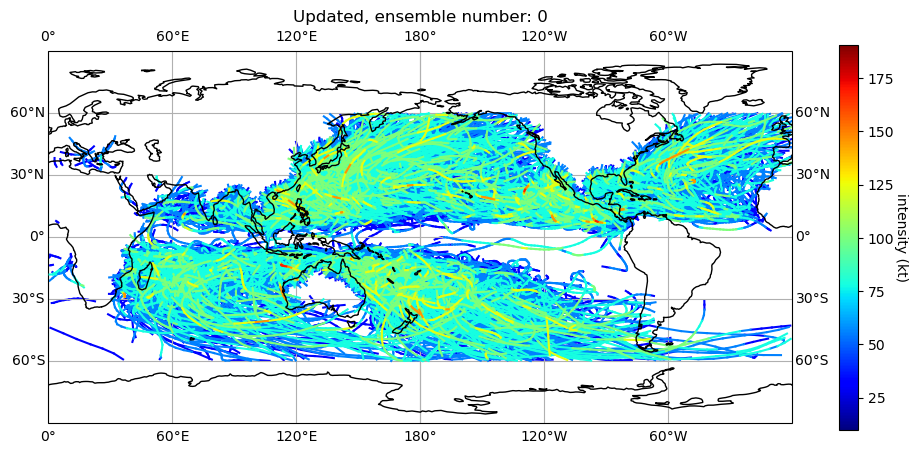

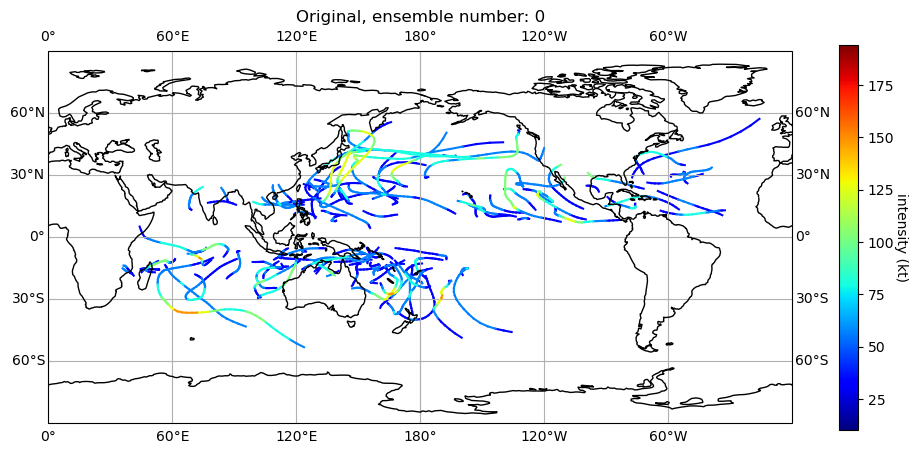

In [8]:
spaghettiplots(ds_new, ensnum, title = 'Updated')
spaghettiplots(ds_old, ensnum, title = 'Original')

## Difference between original 

Files for comparison located at: `/data0/clee/ERA5/wdir/netcdf/global*pre.nc`
- each file is one ensemble run, so i think i can grab any of them 
- so we want files `global_2019_2ens`

### Density maps
- TC genesis per 5x5 box
- Lee et al. 2018, Figure 1 


. a. genesis 
	2. b. tracks
	3. track points (if valid intensity data)
		1. show differences (mine minus chia-ying)





In [9]:
def get_lonlat_points(dspy):
    """Flatten lon/lat/wspd to 1D point clouds, dropping NaNs."""
    lon_b, lat_b, wspd_b = xr.broadcast(dspy['longitude'], dspy['latitude'], dspy['Mwspd'])
    df = pd.DataFrame({
        'lon': lon_b.values.ravel(),
        'lat': lat_b.values.ravel(),
        'wspd': wspd_b.values.ravel(),
    })
    df = df.dropna(subset=['lon', 'lat', 'wspd'])

    lon = df['lon'].to_numpy(copy=True)
    lon[lon <= 0] = lon[lon <= 0] + 360
    lat = df['lat'].to_numpy(copy=True)
    return lon, lat


def density_grid(dspy, lon_bins, lat_bins):
    """Bin lon/lat points onto a fixed grid, returning raw counts."""
    lon, lat = get_lonlat_points(dspy)
    output = stats.binned_statistic_2d(lon, lat, values=None, statistic='count', bins=[lon_bins, lat_bins])
    return output.statistic, output.x_edge, output.y_edge


def _add_map_features(ax, title):
    ax.set_title(title)
    ax.set_global()
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                       linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(range(-180, 180, 60))
    gl.ylocator = mticker.FixedLocator(range(-90, 90, 15))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER


def densityplots(dspy, genesis=False, title=None, lon_bins=None, lat_bins=None):
    if lon_bins is None:
        lon_bins = np.linspace(0, 360, 121)
    if lat_bins is None:
        lat_bins = np.linspace(-90, 90, 101)

    grid, x_edge, y_edge = density_grid(dspy, lon_bins, lat_bins)

    fig = plt.figure(figsize=(12, 5))
    data_crs = ccrs.PlateCarree()
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    plot1 = plt.pcolormesh(x_edge, y_edge, grid.T, transform=data_crs, 
                           vmin = 0, vmax = 3200,
                           cmap='hot_r')
    _add_map_features(ax, title)
    plt.colorbar(plot1, ax=ax, pad=.015, aspect=10)
    plt.show()


def densitydiffplot(ds_a, ds_b, title=None, label_a='New', label_b='Old'):
    lon_bins = np.linspace(0, 360, 121)
    lat_bins = np.linspace(-90, 90, 101)

    grid_a, x_edge, y_edge = density_grid(ds_a, lon_bins, lat_bins)
    grid_b, _, _ = density_grid(ds_b, lon_bins, lat_bins)

    diff = grid_a - grid_b
    vmax = np.nanmax(np.abs(diff))

    fig = plt.figure(figsize=(12, 5))
    data_crs = ccrs.PlateCarree()
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    plot1 = plt.pcolormesh(x_edge, y_edge, diff.T, transform=data_crs,
                           cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    _add_map_features(ax, title or f'{label_a} minus {label_b}')
    plt.colorbar(plot1, ax=ax, pad=.015, aspect=10, label='Difference')
    plt.show()

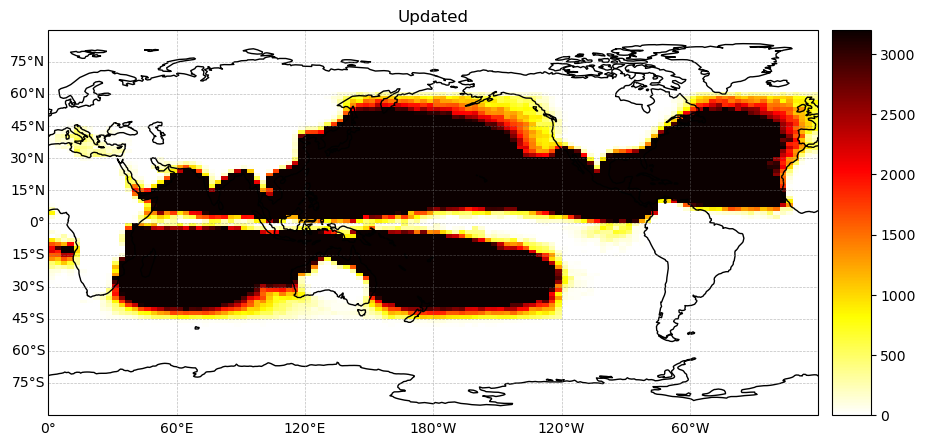

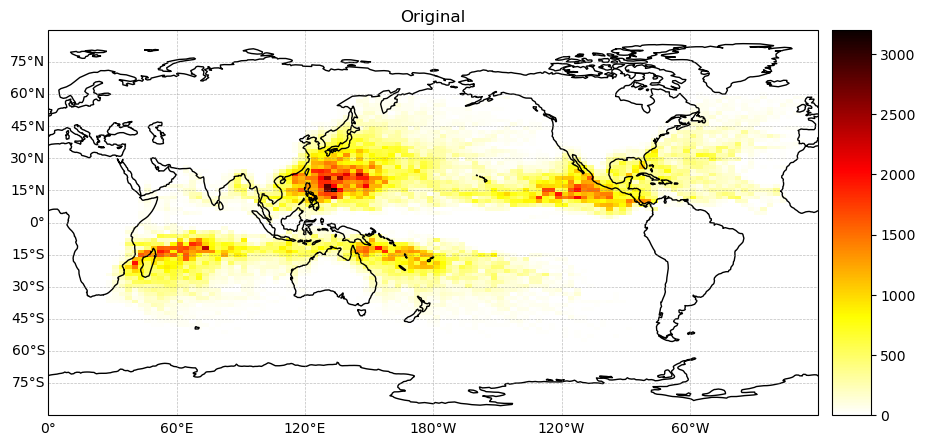

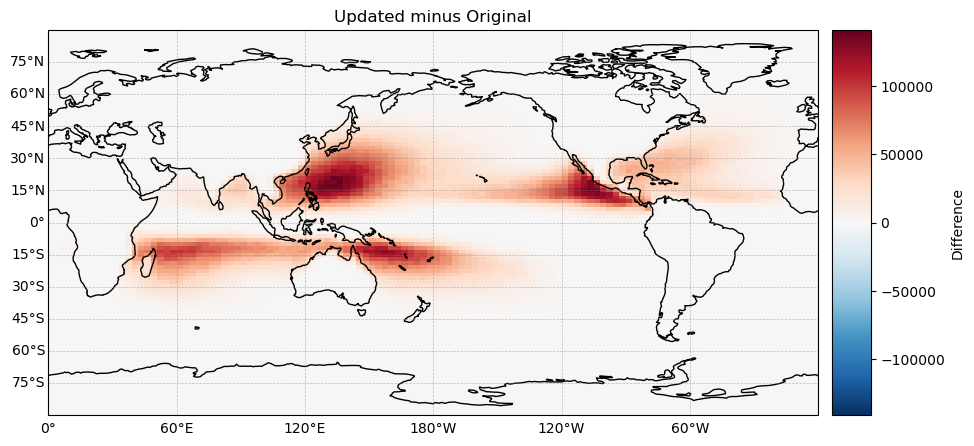

In [10]:
densityplots(ds_new, title='Updated')
densityplots(ds_old, title='Original')
densitydiffplot(ds_new, ds_old, label_a='Updated', label_b='Original')

### TC genesis maps

In [11]:
def get_genesis_points(dspy):
    """First valid (lon, lat) along `lifelength` for each storm — replaces
    get_lonlat_points when you want genesis locations instead of full tracks."""
    lon = dspy['longitude']
    lat = dspy['latitude']

    valid = lon.notnull() & lat.notnull()
    has_valid = valid.any(dim='lifelength')     # did this storm ever have a position?
    first_idx = valid.argmax(dim='lifelength')   # index of first True along lifelength

    glon = lon.isel(lifelength=first_idx).where(has_valid)
    glat = lat.isel(lifelength=first_idx).where(has_valid)

    glon = glon.values.ravel()
    glat = glat.values.ravel()

    mask = ~np.isnan(glon) & ~np.isnan(glat)
    glon, glat = glon[mask], glat[mask]

    glon = np.where(glon <= 0, glon + 360, glon)
    return glon, glat


def genesis_density_grid(dspy, lon_bins, lat_bins):
    """Same role as density_grid, but bins genesis points instead of all track points."""
    lon, lat = get_genesis_points(dspy)
    output = stats.binned_statistic_2d(lon, lat, values=None, statistic='count', bins=[lon_bins, lat_bins])
    return output.statistic, output.x_edge, output.y_edge


def genesisplots(dspy, title=None, lon_bins=None, lat_bins=None):
    """Same as densityplots, but for genesis counts."""
    # if lon_bins is None:
    #     lon_bins = np.linspace(0, 360, 121)
    # if lat_bins is None:
    #     lat_bins = np.linspace(-90, 90, 101)
    if lon_bins is None:
        lon_bins = np.arange(0, 361, 5)      # 5° longitude bins
    if lat_bins is None:
        lat_bins = np.arange(-90, 91, 5)     # 5° latitude bins


    grid, x_edge, y_edge = genesis_density_grid(dspy, lon_bins, lat_bins)

    fig = plt.figure(figsize=(12, 5))
    data_crs = ccrs.PlateCarree()
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    ## not log
    # plot1 = plt.pcolormesh(x_edge, y_edge, grid.T, transform=data_crs, cmap='hot_r')
    # plt.colorbar(plot1, ax=ax, pad=.015, aspect=10)


    ## log
    grid = np.ma.masked_where(grid == 0, grid)
    plot1 = plt.pcolormesh(
        x_edge,
        y_edge,
        grid.T,
        transform=data_crs,
        cmap="hot_r",
        norm=LogNorm(vmin=1, vmax=100)
    )

    _add_map_features(ax, title)

    cbar = plt.colorbar(plot1, ax=ax, pad=0.015, aspect=10)
    cbar.set_ticks([1, 10, 100])
    cbar.set_ticklabels([r"$10^0$", r"$10^1$", r"$10^2$"])


    plt.show()


def genesisdiffplot(ds_a, ds_b, title=None, label_a='New', label_b='Old'):
    """Same as densitydiffplot, but for genesis counts."""
    ### 5x5 degree bins covering the globe ###
    lon_bins = np.arange(0, 365, 5)   
    lat_bins = np.arange(-90, 95, 5)  
    # lon_edges = np.arange(0, 365, 5)    # 72 boxes
    # lat_edges = np.arange(-90, 95, 5)   # 36 boxes
    #genesis_grid = np.zeros((len(lat_edges) - 1, len(lon_edges) - 1))
    
    # lon_bins = np.linspace(0, 360, 121)
    # lat_bins = np.linspace(-90, 90, 101)

    grid_a, x_edge, y_edge = genesis_density_grid(ds_a, lon_bins, lat_bins)
    grid_b, _, _ = genesis_density_grid(ds_b, lon_bins, lat_bins)

    diff = grid_a - grid_b
    vmax = np.nanmax(np.abs(diff))

    fig = plt.figure(figsize=(12, 5))
    data_crs = ccrs.PlateCarree()
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    plot1 = plt.pcolormesh(x_edge, y_edge, diff.T, transform=data_crs,
                           cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    _add_map_features(ax, title or f'{label_a} minus {label_b}')
    plt.colorbar(plot1, ax=ax, pad=.015, aspect=10, label='Difference')
    plt.show()

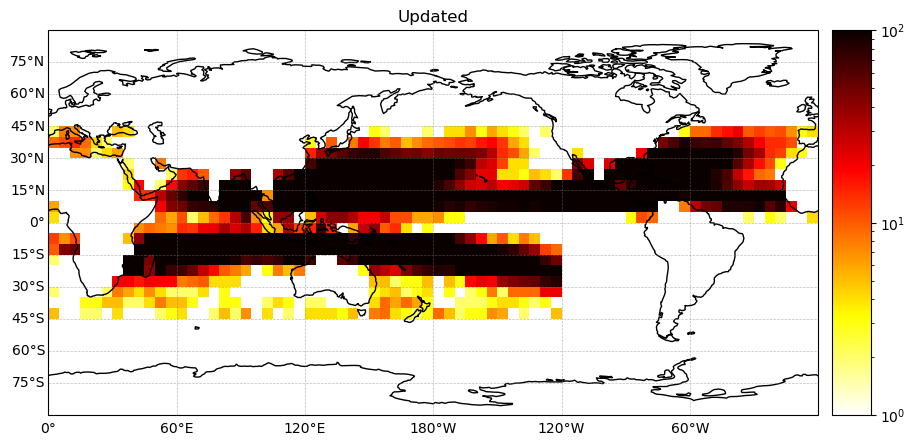

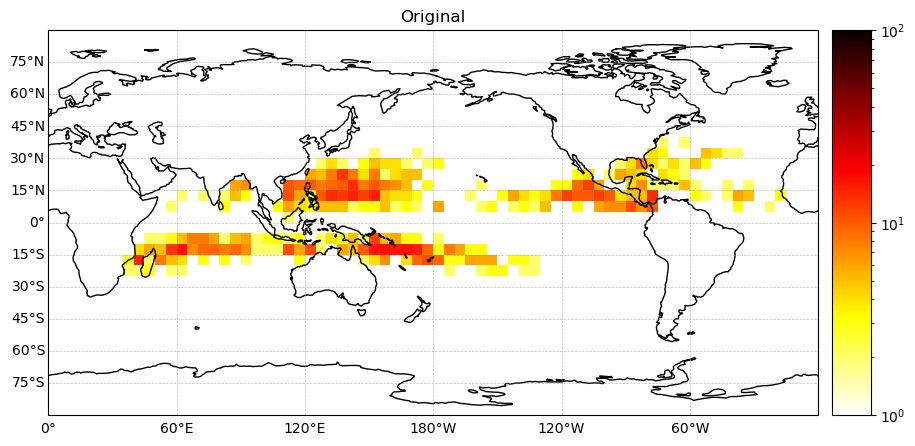

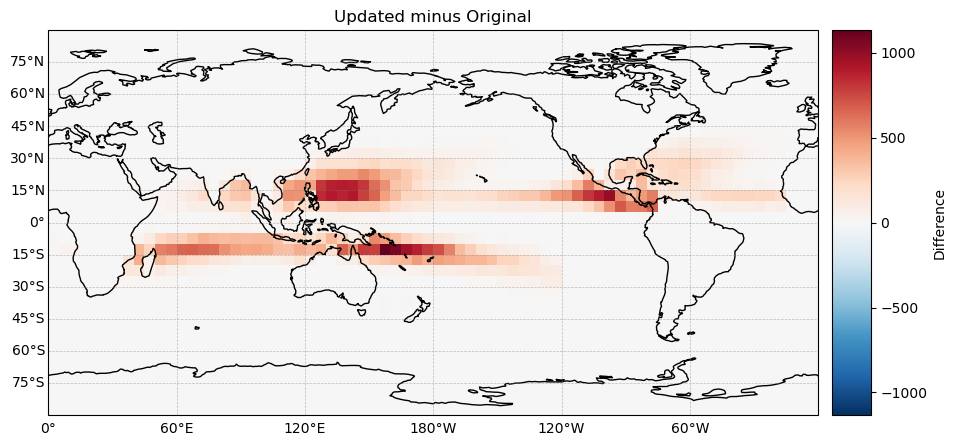

In [12]:
genesisplots(ds_new, title='Updated')
genesisplots(ds_old, title='Original')
genesisdiffplot(ds_new, ds_old, label_a='Updated', label_b='Original')

### Frequency

In [13]:
def frequency(dspy,ensnum,intensity,keyword='both',basin=True):
    """
    annual frequency
    takes argument of filename as string and the minimum intensity we are calculating
    keyword options are seasonal or annual (default is both)
    if basin = False, do not separate by basin
    """
    #dspy =xr.open_dataset(filename)
    #figname = Path(filename).stem
    xbin,ybin,basinMap = getbasinMap()
    intENS=40
    #y1 = dspy.year.values.min()
    #y2 = dspy.year.values.max()

    y1 = gv.Year1
    y2 = gv.Year2

    #annual frequency first
    if keyword == 'both' or 'annual':
        years = np.arange(y1,y2+1)
        freq_crh = np.zeros([intENS,years.shape[0]])
        freq_crh_atl = np.zeros([intENS,years.shape[0]])
        freq_crh_enp = np.zeros([intENS,years.shape[0]])
        freq_crh_wpc = np.zeros([intENS,years.shape[0]])
        freq_crh_ni = np.zeros([intENS,years.shape[0]])
        freq_crh_si = np.zeros([intENS,years.shape[0]])
        freq_crh_aus = np.zeros([intENS,years.shape[0]])
        freq_crh_sp = np.zeros([intENS,years.shape[0]])
        lon0,lat0 = dspy.longitude.values[0],dspy.latitude.values[0]
        basins = defineBasin(lon0,lat0,xbin,ybin,basinMap)
        df = pd.to_datetime(dspy.time[0],unit='D')
        Vmax = np.nanmax(dspy.Mwspd,axis=1)
        Vmax[Vmax<34]=float('NaN')
        Vmax_label = np.zeros(Vmax.shape)
        Vmax_label[Vmax==Vmax]= 1
        Year = np.repeat(np.array(df.year),40).reshape(df.year.shape[0],40).T
        Year = Year*Vmax_label
        freq_crh=np.array([np.histogram(Year[iN][basins>=0],np.arange(y1-0.5,y2+0.5,1))[0] for iN in range(40)])
        freq_crh_atl = np.array([np.histogram(Year[iN][basins==1],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
        freq_crh_enp = np.array([np.histogram(Year[iN][basins==2],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
        freq_crh_wpc = np.array([np.histogram(Year[iN][basins==3],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
        freq_crh_ni = np.array([np.histogram(Year[iN][basins==4],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
        freq_crh_si = np.array([np.histogram(Year[iN][basins==5],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
        freq_crh_aus = np.array([np.histogram(Year[iN][basins==6],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
        freq_crh_sp = np.array([np.histogram(Year[iN][basins==7],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
        if basin == False:
            plt.plot(np.arange(y1,y2+1),freq_crh[ensnum,:])
            plt.savefig(figname+'annualfrequency.png')
            plt.show()
        elif basin == True:
            fig, axs = plt.subplots(3, 3, figsize=(15, 15))
            fig.delaxes(axs[2,2])
            fig.delaxes(axs[2,1])

            axs[0, 0].plot(np.arange(y1,y2+1), freq_crh_atl[ensnum,:])
            axs[0, 0].set_title("atl")

            axs[1, 0].plot(np.arange(y1,y2+1), freq_crh_enp[ensnum,:])
            axs[1, 0].set_title("enp")

            axs[2, 0].plot(np.arange(y1,y2+1), freq_crh_wpc[ensnum,:])
            axs[2, 0].set_title("wpc")

            axs[0, 1].plot(np.arange(y1,y2+1), freq_crh_aus[ensnum,:])
            axs[0, 1].set_title("aus")

            axs[1, 1].plot(np.arange(y1,y2+1), freq_crh_ni[ensnum,:])
            axs[1, 1].set_title("ni")

            axs[0, 2].plot(np.arange(y1,y2+1), freq_crh_si[ensnum,:])
            axs[0, 2].set_title("si")

            axs[1, 2].plot(np.arange(y1,y2+1), freq_crh_sp[ensnum,:])
            axs[1, 2].set_title("sp")

            plt.setp(axs,ylabel = 'ocurrences')

            #plt.savefig(figname+'annualfrequency.png')
            plt.show()
    if keyword == 'both' or 'seasonal':
        months = np.arange(1,13)
        freq_crh = np.zeros([intENS,months.shape[0]])
        freq_crh_atl = np.zeros([intENS,months.shape[0]])
        freq_crh_enp = np.zeros([intENS,months.shape[0]])
        freq_crh_wpc = np.zeros([intENS,months.shape[0]])
        freq_crh_ni = np.zeros([intENS,months.shape[0]])
        freq_crh_si = np.zeros([intENS,months.shape[0]])
        freq_crh_aus = np.zeros([intENS,months.shape[0]])
        freq_crh_sp = np.zeros([intENS,months.shape[0]])
        lon0,lat0 = dspy.longitude.values[0],dspy.latitude.values[0]
        basins = defineBasin(lon0,lat0,xbin,ybin,basinMap)
        df = pd.to_datetime(dspy.time[0],unit='D')
        Vmax = np.nanmax(dspy.Mwspd,axis=1)
        Vmax[Vmax<34]=float('NaN')
        Vmax_label = np.zeros(Vmax.shape)
        Vmax_label[Vmax==Vmax]= 1
        Month = np.repeat(np.array(df.month),40).reshape(df.month.shape[0],40).T
        Month = Month*Vmax_label
        freq_crh=np.array([np.histogram(Month[iN][basins>=0],np.arange(0.5,13.5,1))[0] for iN in range(40)])
        freq_crh_atl = np.array([np.histogram(Month[iN][basins==1],np.arange(0.5,13.5,1))[0] for iN in range(40)])
        freq_crh_enp = np.array([np.histogram(Month[iN][basins==2],np.arange(0.5,13.5,1))[0] for iN in range(40)])
        freq_crh_wpc = np.array([np.histogram(Month[iN][basins==3],np.arange(0.5,13.5,1))[0] for iN in range(40)])
        freq_crh_ni = np.array([np.histogram(Month[iN][basins==4],np.arange(0.5,13.5,1))[0] for iN in range(40)])
        freq_crh_si = np.array([np.histogram(Month[iN][basins==5],np.arange(0.5,13.5,1))[0] for iN in range(40)])

        #filename = figname+'seasonalfrequency.png'
        if basin == False:
            plt.plot(np.arange(1,13),freq_crh[ensnum,:])
            #plt.savefig(uniquify(filename))
            plt.show()
        if basin == True:
            fig, axs = plt.subplots(3, 3, figsize=(15, 15))
            fig.delaxes(axs[2,2])
            fig.delaxes(axs[2,1])
            months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

            axs[0, 0].plot(np.arange(1,13), freq_crh_atl[ensnum,:])
            axs[0, 0].set_title("atl")

            axs[1, 0].plot(np.arange(1,13), freq_crh_enp[ensnum,:])
            axs[1, 0].set_title("enp")

            axs[2, 0].plot(np.arange(1,13), freq_crh_wpc[ensnum,:])
            axs[2, 0].set_title("wpc")

            axs[0, 1].plot(np.arange(1,13), freq_crh_aus[ensnum,:])
            axs[0, 1].set_title("aus")

            axs[1, 1].plot(np.arange(1,13), freq_crh_ni[ensnum,:])
            axs[1, 1].set_title("ni")

            axs[0, 2].plot(np.arange(1,13), freq_crh_si[ensnum,:])
            axs[0, 2].set_title("si")

            axs[1, 2].plot(np.arange(1,13), freq_crh_sp[ensnum,:])
            axs[1, 2].set_title("sp")

            plt.setp(axs,ylabel = 'ocurrences', xticks = np.linspace(1,12,12), xticklabels = months)

            #plt.savefig(uniquify(filename))
            plt.show()

        return()

In [14]:
# print('Original')
# frequency(ds_old, ensnum, intensity)

# print('Updated')
# frequency(ds_new, ensnum, intensity)

### Comparing A_

updated lives in `gv.pre_path`
original ives in `/xpt/taroko.local/data0/clee/ERA5/wdir`

issue: 
- still trying to figure out what is actually wrong with the updated A and why some of the original A do not have data for some days 
- 


notes:
- when `yrmo = '200101'` the original A data is the same for multiple days, however this is not true of all year and month combinations, e.g., when `yrmo = '200108'` the data varies from day to day.


In [15]:
import xarray as xr

#yrmo = '200101'
#yrmo = '200108'
yrmo = '200511'


### FIGURE OUT IF ONLY JANUARY? 

newA = xr.open_dataset(f'{gv.pre_path}A_{yrmo}.nc').load()
oldA = xr.open_dataset(f'/xpt/taroko.local/data0/clee/ERA5/wdir/A_{yrmo}.nc').load()

Text(0.5, 0.98, 'Original A plots sometimes have same values for multiple days')

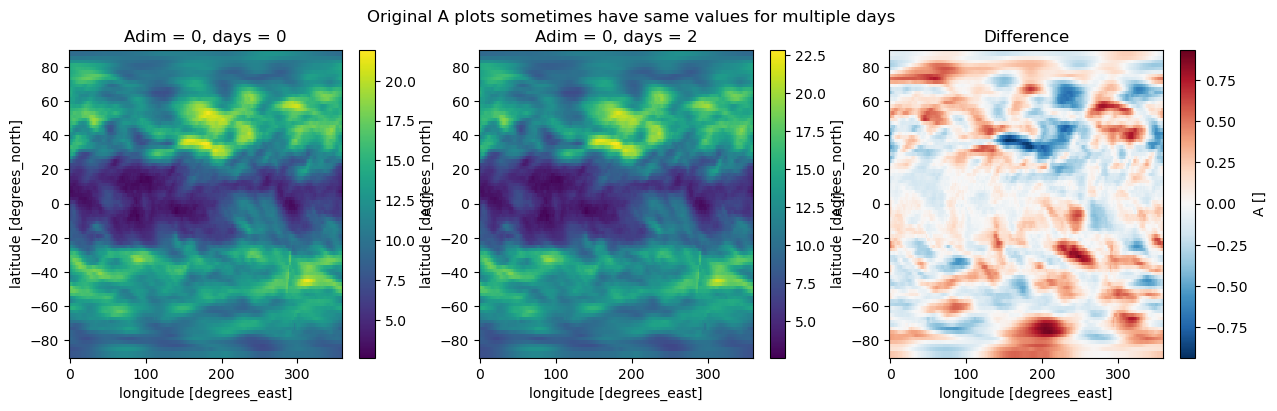

In [16]:
#(oldA.sel(Adim = 0, days = 1) == oldA.sel(Adim = 0, days = 2)).A

fig, ax = plt.subplots(ncols = 3, figsize = (15, 4))

oldA.sel(Adim = 0, days = 0).A.plot(ax = ax[0])
ax[0].set_title('Adim = 0, days = 0')
oldA.sel(Adim = 0, days = 2).A.plot(ax = ax[1])
ax[1].set_title('Adim = 0, days = 2')
(oldA.sel(Adim = 0, days = 0).copy()-oldA.sel(Adim = 0, days = 2).copy()).A.plot(ax = ax[2])
ax[2].set_title('Difference')

plt.suptitle('Original A plots sometimes have same values for multiple days')

Text(0.5, 0.98, 'Updated A plots also have same values for multiple days')

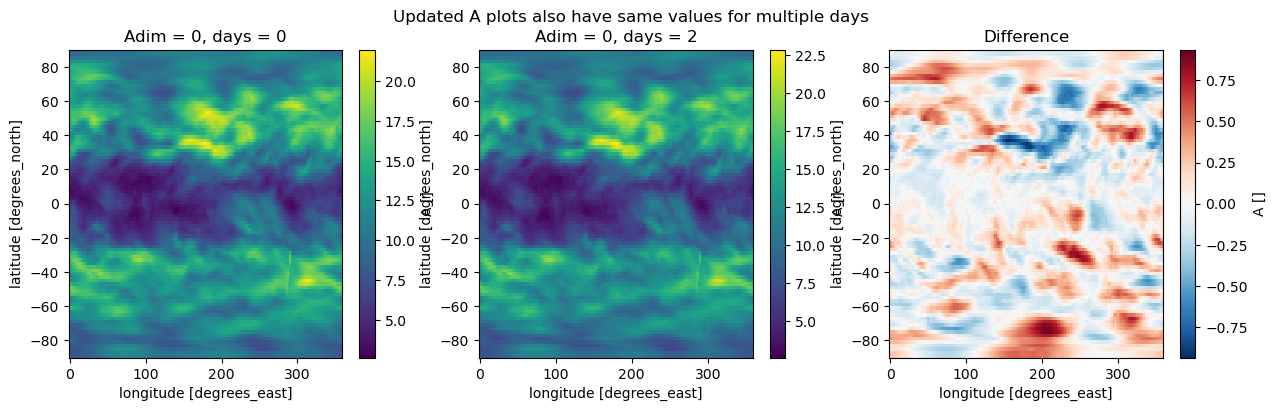

In [17]:
#(oldA.sel(Adim = 0, days = 1) == oldA.sel(Adim = 0, days = 2)).A

fig, ax = plt.subplots(ncols = 3, figsize = (15, 4))

newA.sel(Adim = 0, days = 0).A.plot(ax = ax[0])
ax[0].set_title('Adim = 0, days = 0')
newA.sel(Adim = 0, days = 2).A.plot(ax = ax[1])
ax[1].set_title('Adim = 0, days = 2')
(newA.sel(Adim = 0, days = 0)-newA.A.sel(Adim = 0, days = 2)).A.plot(ax = ax[2])
ax[2].set_title('Difference')

plt.suptitle('Updated A plots also have same values for multiple days')

Original


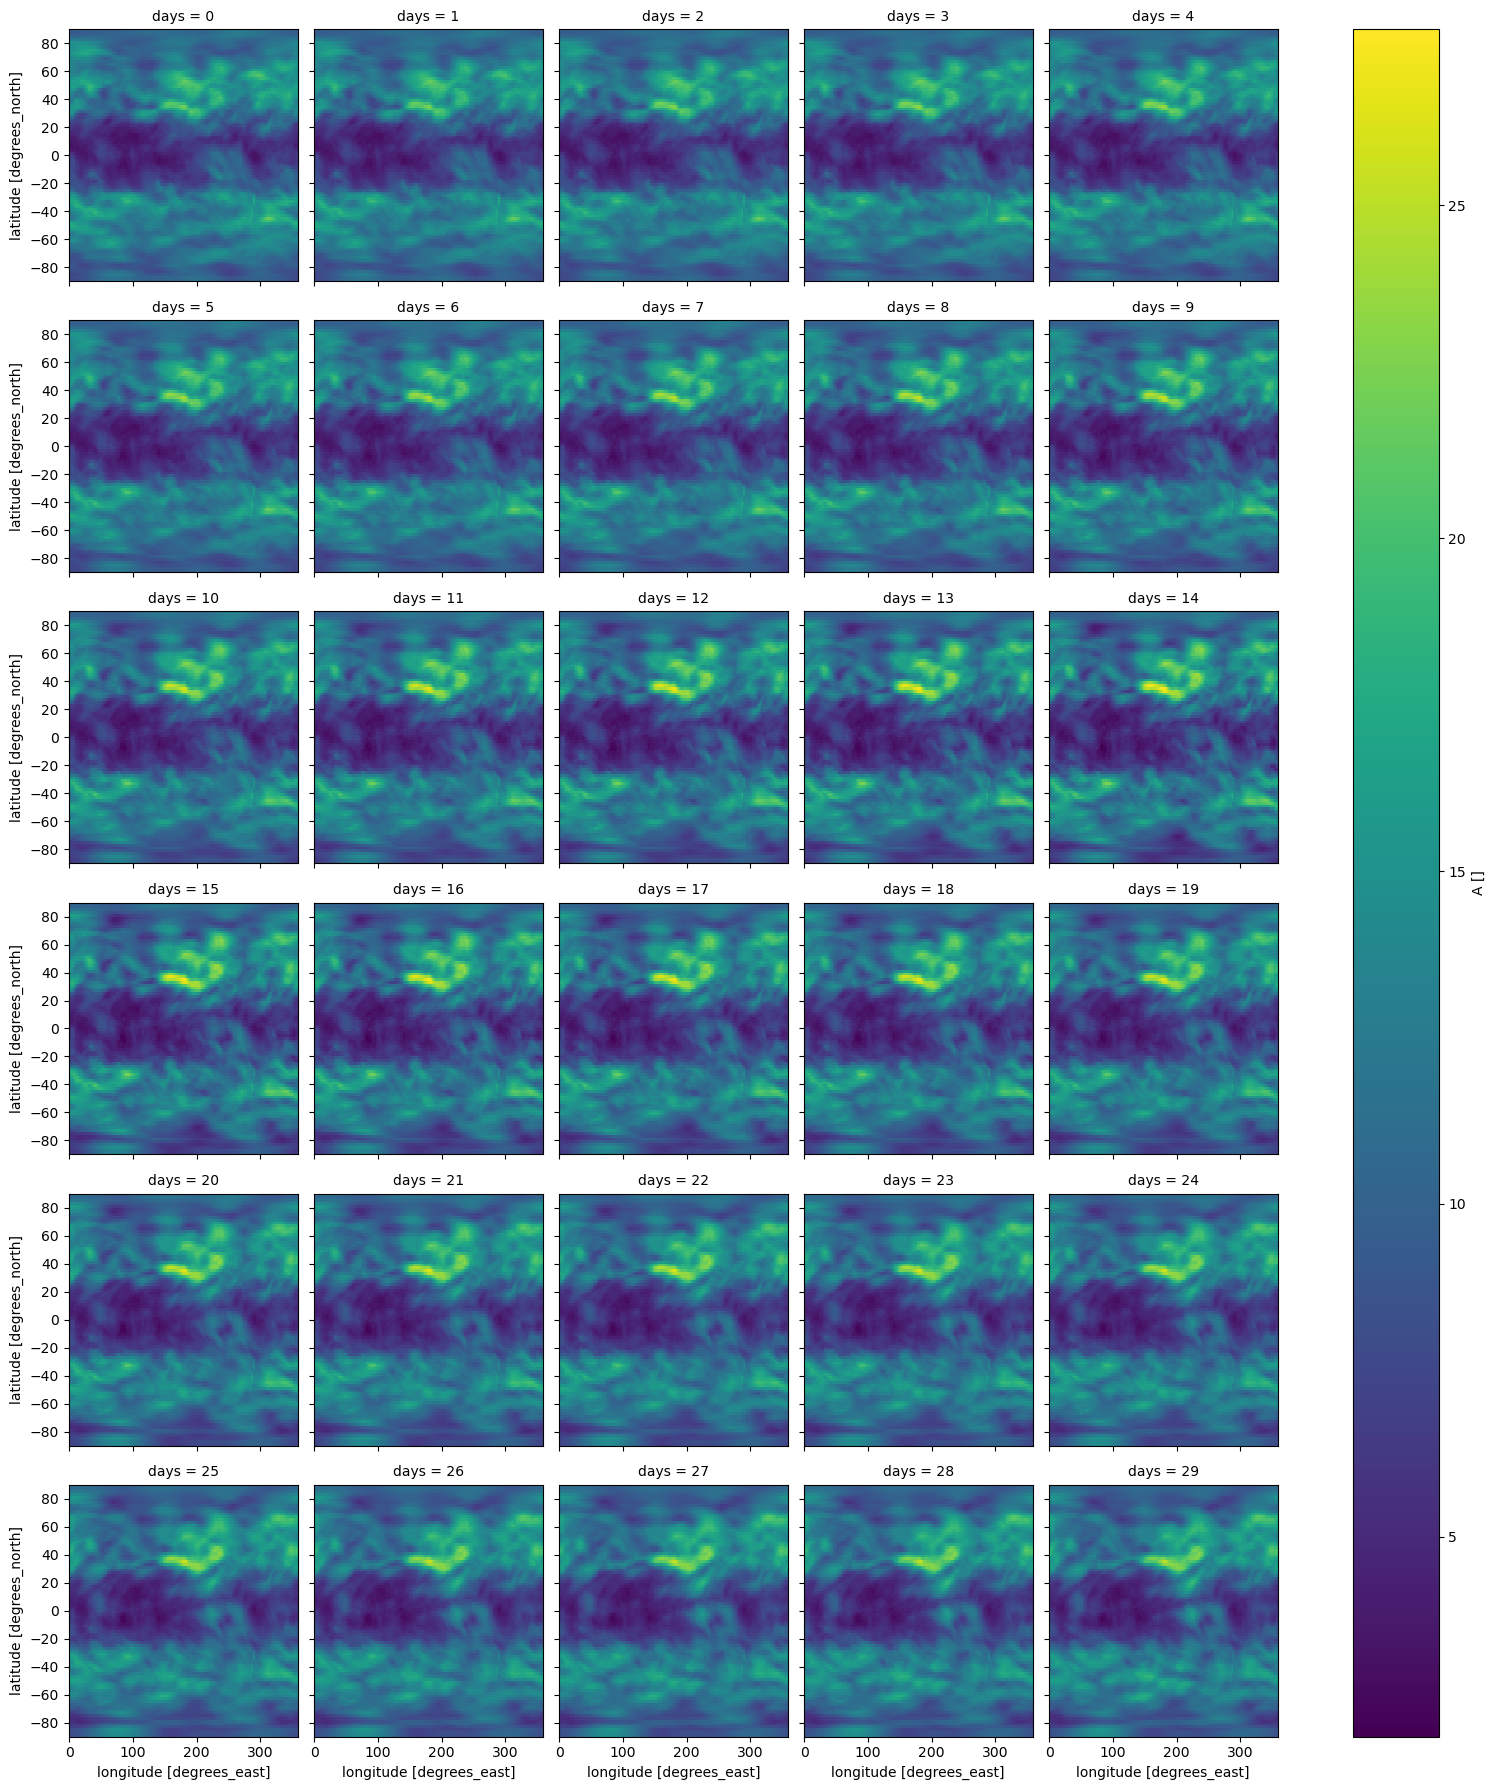

Updated


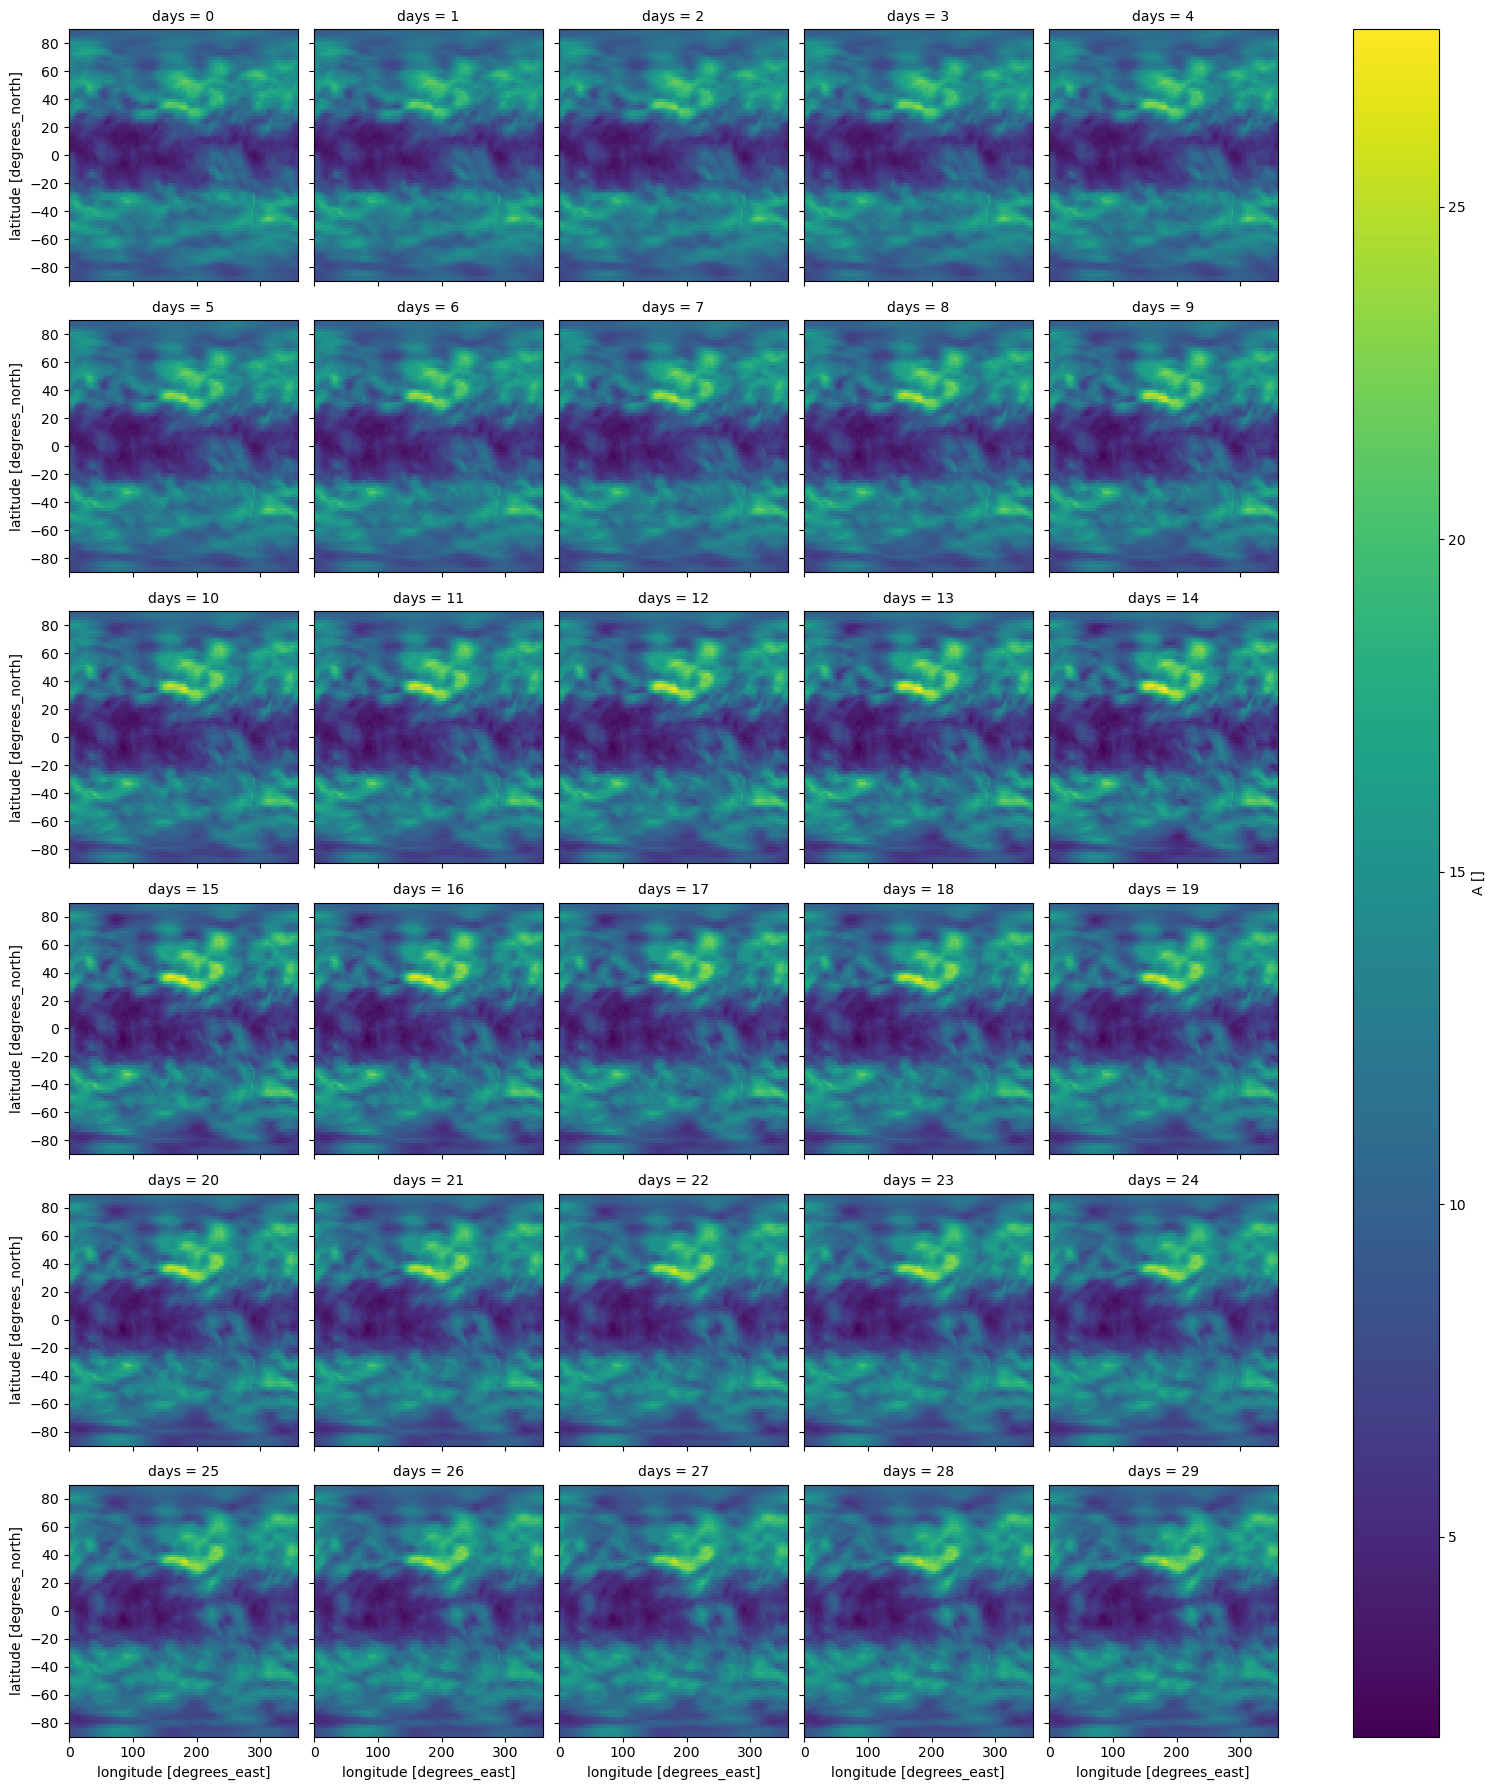

In [18]:
print('Original')
oldA.sel(Adim = 0).A.plot(col = 'days', col_wrap = 5)
plt.show()

print('Updated')
newA.sel(Adim = 0).A.plot(col = 'days', col_wrap = 5)
plt.show()
        
        

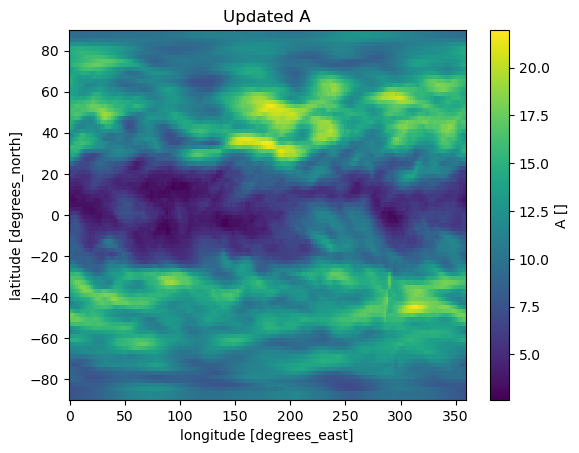

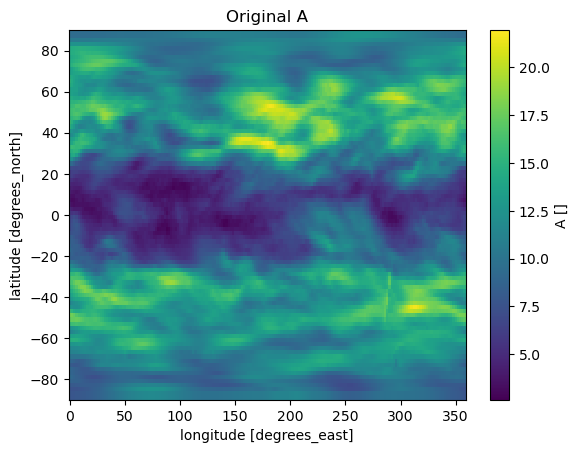

Text(0.5, 1.0, 'Difference')

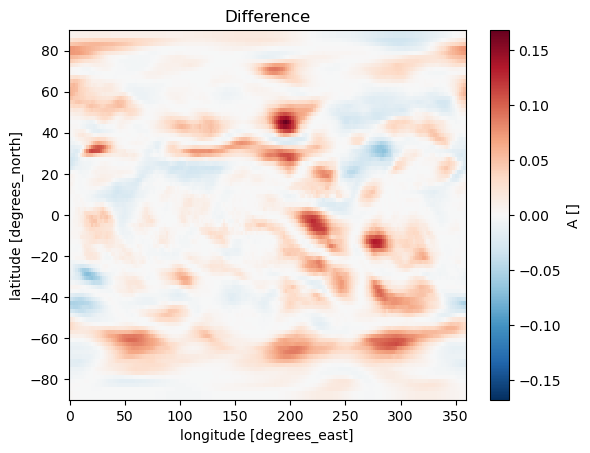

In [19]:
Adim = 0
days = 0

newA.sel(days = days, Adim = Adim).A.plot()
plt.title('Updated A')
plt.show()

oldA.sel(days = days, Adim = Adim).A.plot()
plt.title('Original A')
plt.show()

(newA.sel(days = days, Adim = Adim).A - oldA.sel(days = days, Adim = Adim).A).plot()
plt.title('Difference')

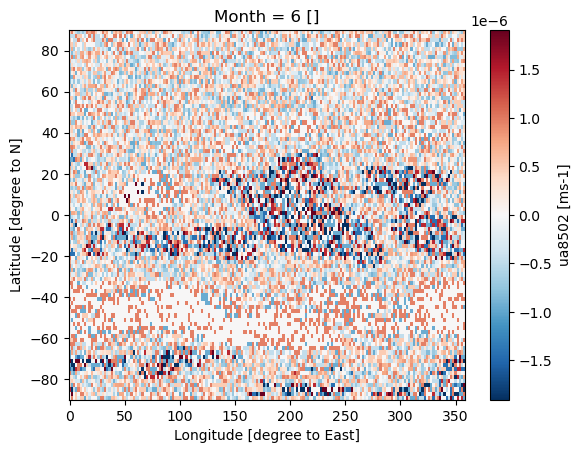

In [20]:
yr = '2001'
newyr = xr.open_dataset(f'{gv.pre_path}{yr}_r1i1p1f1.nc').load()
oldyr = xr.open_dataset(f'/xpt/taroko.local/data0/clee/ERA5/wdir/{yr}_r1i1p1f1.nc').load()
(newyr.isel(Month = 5).ua8502- oldyr.isel(Month = 5).ua8502).plot()

In [21]:
newcov = xr.open_dataset(f'{gv.pre_path}Cov_{yr}.nc').load()
# oldcov = xr.open_dataset(f'/xpt/taroko.local/data0/clee/ERA5/pre/Cov_{yr}.nc').load()
# #(newyr.isel(Month = 5).ua8502- oldyr.isel(Month = 5).ua8502).plot()

In [22]:
### Cov_{yr}.nc only has values for january? 
print(f'Cov_{yr} for February {newcov.isel(month = 1).max()}')
print(f'Cov_{yr} for January {newcov.isel(month = 0).max()}')


Cov_2001 for February <xarray.Dataset> Size: 44B
Dimensions:     ()
Coordinates:
    month       int32 4B 2
Data variables:
    u200pu200p  float32 4B 627.1
    u200pv200p  float32 4B 257.3
    u200pu850p  float32 4B 240.0
    u200pv850p  float32 4B 94.42
    v200pv200p  float32 4B 801.3
    v200pu850p  float32 4B 138.5
    v200pv850p  float32 4B 198.7
    u850pu850p  float32 4B 191.6
    u850pv850p  float32 4B 81.72
    v850pv850p  float32 4B 185.9
Cov_2001 for January <xarray.Dataset> Size: 44B
Dimensions:     ()
Coordinates:
    month       int32 4B 1
Data variables:
    u200pu200p  float32 4B 650.3
    u200pv200p  float32 4B 200.3
    u200pu850p  float32 4B 200.6
    u200pv850p  float32 4B 107.2
    v200pv200p  float32 4B 630.7
    v200pu850p  float32 4B 87.13
    v200pv850p  float32 4B 178.5
    u850pu850p  float32 4B 190.9
    u850pv850p  float32 4B 89.1
    v850pv850p  float32 4B 208.2


 ### Intensity distribution
	1. figure 3 
	2. plot several to show differences 

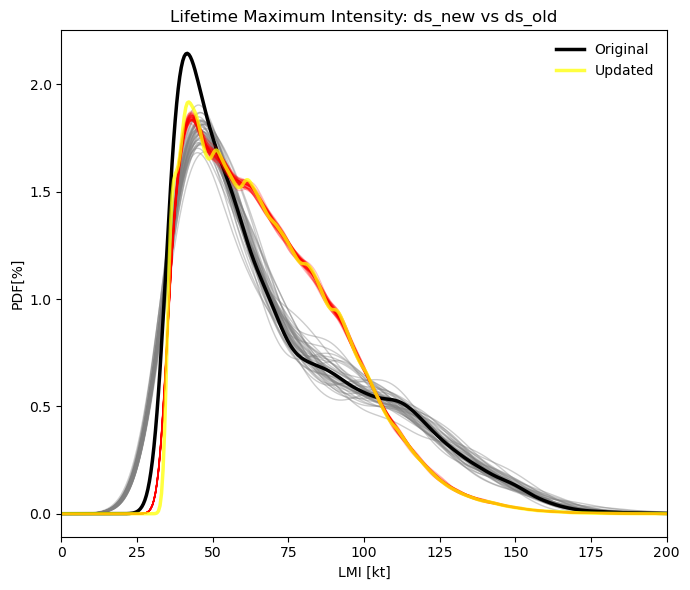

In [23]:
## Common x-grid for evaluating the smoothed PDF curves (kt)
X_MIN, X_MAX = 0, 200
X_GRID = np.linspace(X_MIN, X_MAX, 400)


## calculate lifetime maximum intensity (LMI) per storm, per ensemble member
## Mwspd dims: (year_dim, ensembleNum, lifelength, stormID)
##    -> max over lifelength -> (year_dim, ensembleNum, stormID)

def lmi_by_ensemble(ds, var="Mwspd", life_dim="lifelength", ens_dim="ensembleNum"):
    """
    Returns a dict: 
        {ensemble_index: 1D np.array of LMI values (NaNs dropped)}
    """
    lmi = ds[var].max(dim=life_dim, skipna=True)  # (year_dim, ensembleNum, stormID)
    out = {}
    for i, e in enumerate(ds[ens_dim].values):
        vals = lmi.isel({ens_dim: i}).values.ravel()
        vals = vals[~np.isnan(vals)]
        out[e] = vals
    return out


def kde_pdf_percent(values, grid=X_GRID):
    """
    plot gaussian-KDE smoothed PDF as a percent

    """
    if len(values) < 2:
        return np.zeros_like(grid)
    kde = gaussian_kde(values)
    density = kde(grid)             ## calculate pdf
    density_pct = density * 100     ## convert to percentage
    return density_pct


ens_new = lmi_by_ensemble(ds_new)
ens_old = lmi_by_ensemble(ds_old)

# Pooled - combine all ensemble members  
pooled_new = np.concatenate(list(ens_new.values()))
pooled_old = np.concatenate(list(ens_old.values()))


fig, ax = plt.subplots(figsize=(7, 6))

##  ds_old: original data
for vals in ens_old.values():
    pdf = kde_pdf_percent(vals)
    ax.plot(X_GRID, pdf, color="gray", alpha=0.4, linewidth=1)

pdf_old_mean = kde_pdf_percent(pooled_old)
ax.plot(X_GRID, pdf_old_mean, color="black", linewidth=2.5, label="Original")

## ds_new: updated data 
for vals in ens_new.values():
    pdf = kde_pdf_percent(vals)
    ax.plot(X_GRID, pdf, color="red", alpha=0.25, linewidth=1)

pdf_new_mean = kde_pdf_percent(pooled_new)
ax.plot(X_GRID, pdf_new_mean, color="yellow", linewidth=2.5, alpha = 0.75, label="Updated")

ax.set_xlim(X_MIN, X_MAX)
#ax.set_ylim(0, 10)
ax.set_xlabel("LMI [kt]")
ax.set_ylabel("PDF[%]")
ax.set_title("Lifetime Maximum Intensity: ds_new vs ds_old")
ax.legend(frameon=False)

fig.tight_layout()


plt.show()


### why is the mean larger than the ensemble members
### look for shoulder -- should have a shoulder 


### Landfall counts
-  track density figure 8 -- lee et al 2018 

### Return periods

In [24]:
# #def density_genesis_map(kind = 'Updated')

# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import matplotlib.ticker as mticker
# import cartopy.crs as ccrs
# import cartopy as cart
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# years = [str(year) for year in np.arange(gv.Year1, gv.Year2)]

# ### 5x5 degree bins covering the globe ###
# lon_bins = np.arange(0, 365, 5)   
# lat_bins = np.arange(-90, 95, 5)  
# lon_edges = np.arange(0, 365, 5)    # 72 boxes
# lat_edges = np.arange(-90, 95, 5)   # 36 boxes
# genesis_grid = np.zeros((len(lat_edges) - 1, len(lon_edges) - 1))

# for year in years:
#     filename = f'output/ERA5_{year}_ens000.nc'
#     dspy = xr.open_dataset(filename)

#     lon_all = np.array(dspy['longitude'])
#     lat_all = np.array(dspy['latitude'])

#     n_storms = lon_all.shape[1]
#     genesis_lon, genesis_lat = [], []

#     for i in range(n_storms):
#         lon_i = lon_all[:, i]
#         lat_i = lat_all[:, i]

#         valid = ~np.isnan(lon_i) & ~np.isnan(lat_i)
#         if not valid.any():
#             continue
#         first_idx = np.argmax(valid)
#         glon = lon_i[first_idx]
#         if glon <= 0:
#             glon += 360
#         genesis_lon.append(glon)
#         genesis_lat.append(lat_i[first_idx])

#     counts, _, _ = np.histogram2d(np.array(genesis_lon), np.array(genesis_lat),
#                                 bins=[lon_edges, lat_edges])
#     genesis_grid += counts.T   

# genesis_plot = np.where(genesis_grid == 0, np.nan, genesis_grid)

# fig = plt.figure(figsize=(12, 5))
# ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
# ### just look at the ocean basins
# ax.set_extent([0, 360, -50, 50], crs=ccrs.PlateCarree())

# cmap = plt.get_cmap('jet').copy()
# cmap.set_under('white')

# genesis_plot_filled = np.where(np.isnan(genesis_plot), 1e-3, genesis_plot)

# ## log 
# norm = mcolors.LogNorm(vmin=0.5, vmax=max(genesis_grid.max(), 100))

# plot1 = ax.pcolormesh(lon_edges, lat_edges, genesis_plot_filled,
#                     transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)

# ax.coastlines(zorder=100)

# gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
#                 linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# gl.xlocator = mticker.FixedLocator(range(-180, 180, 60))
# gl.ylocator = mticker.FixedLocator(range(-90, 90, 15))
# gl.xformatter = LONGITUDE_FORMATTER
# gl.yformatter = LATITUDE_FORMATTER

# ax.add_feature(cart.feature.BORDERS, color='gray')

# cbar = plt.colorbar(plot1, ax=ax, ticks=[1, 10, 100], extend='min')
# cbar.ax.text(1.6, 0.02, '0', transform=cbar.ax.transAxes, ha='center', va='top')


# ## should be by 5x5º box, but need to double check 
# plt.title(f'Updated CHAZ-ERA5 {gv.Year1}-{gv.Year2} TC genesis counts', fontweight = 'bold', fontsize = 15)
# plt.show()
# plt.savefig(f'figs/Updated_CHAZ_{gv.Year1}-{gv.Year2}_TC_genesis_counts.png') 

In [25]:
## SAME AS ABOVE but with CHIA-YINGS DATA
## SAME AS ABOVE but differences 

In [26]:
# # #input is filename and genesis
# # #arguments for genesis are true or false, making a genesis plot instead of a total density plot if True
# # def densityplots(dspy, genesis=False, title = None):
# #         #dspy = xr.open_dataset(filename)
# #         #figname = Path(filename).stem
# #         longitude = np.array(dspy['longitude'][:]).ravel()
# #         latitude = np.array(dspy['latitude'][:]).ravel()
# #         wspd = np.array(dspy['Mwspd'][:])
# #         fulllon = np.array([])
# #         fulllat = np.array([])
# #         for i in range(len(wspd)):
# #                 winds = wspd[i].ravel()
# #                 df = pd.DataFrame({'lon':longitude, 'lat':latitude,'wspd':winds})
# #                 df = df[df['lon'].notna()]
# #                 df = df[df['lat'].notna()]
# #                 df = df[df['wspd'].notna()]
# #                 lon = np.array(df['lon'])
# #                 lon[lon<=0] = lon[lon<=0]+360
# #                 lat = np.array(df['lat'])
# #                 fulllon = np.hstack([fulllon,lon])
# #                 fulllat = np.hstack([fulllat,lat])

# #         fig = plt.figure(figsize=(12, 5))
# #         #plt.figure(figsize=(6, 6))
# #         data_crs = ccrs.PlateCarree()
# #         ax = plt.axes(projection = ccrs.PlateCarree(central_longitude=180))
# #         output = stats.binned_statistic_2d(fulllon, fulllat, values = None, statistic='count' , bins = [120, 100])
# #         plot1 = plt.pcolormesh(output.x_edge, output.y_edge, output.statistic.T, 
# #                                transform = data_crs, cmap='hot_r')

# #         ax.set_title(title)
# #         ax.set_global()
# #         ax.coastlines()
# #         #ax.gridlines(draw_labels=True)

# #         cbar = plt.colorbar(plot1,ax=ax, pad = .015, aspect=10)
# #         #filename = figname+'density.png'
# #         #plt.savefig(uniquify(filename))

# #         gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
# #                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# #         gl.top_labels = False
# #         gl.right_labels = False
# #         gl.xlocator = mticker.FixedLocator(range(-180, 180, 60))
# #         gl.ylocator = mticker.FixedLocator(range(-90, 90, 15))
# #         gl.xformatter = LONGITUDE_FORMATTER
# #         gl.yformatter = LATITUDE_FORMATTER

# #         plt.show()

# #         return()

# def densityplots(dspy, genesis=False, title=None):
#     # broadcast lon/lat up to Mwspd's full shape, however many dims it has
#     lon_b, lat_b, wspd_b = xr.broadcast(dspy['longitude'], dspy['latitude'], dspy['Mwspd'])

#     df = pd.DataFrame({
#         'lon': lon_b.values.ravel(),
#         'lat': lat_b.values.ravel(),
#         'wspd': wspd_b.values.ravel(),
#     })
#     df = df.dropna(subset=['lon', 'lat', 'wspd'])

#     lon = df['lon'].to_numpy()
#     lon[lon <= 0] = lon[lon <= 0] + 360
#     lat = df['lat'].to_numpy()

#     fulllon = lon
#     fulllat = lat

#     fig = plt.figure(figsize=(12, 5))
#     data_crs = ccrs.PlateCarree()
#     ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
#     output = stats.binned_statistic_2d(fulllon, fulllat, values=None, statistic='count', bins=[120, 100])
#     plot1 = plt.pcolormesh(output.x_edge, output.y_edge, output.statistic.T,
#                            transform=data_crs, cmap='hot_r')

#     ax.set_title(title)
#     ax.set_global()
#     ax.coastlines()

#     cbar = plt.colorbar(plot1, ax=ax, pad=.015, aspect=10)

#     gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
#                        linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
#     gl.top_labels = False
#     gl.right_labels = False
#     gl.xlocator = mticker.FixedLocator(range(-180, 180, 60))
#     gl.ylocator = mticker.FixedLocator(range(-90, 90, 15))
#     gl.xformatter = LONGITUDE_FORMATTER
#     gl.yformatter = LATITUDE_FORMATTER

#     plt.show()

In [27]:
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import matplotlib.ticker as mticker
# import cartopy as cart
# import cartopy.crs as ccrs
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# years = [str(year) for year in np.arange(gv.Year1, gv.Year2)]

# ### 5x5 degree bins covering the globe ###
# lon_edges = np.arange(0, 365, 5)   # 72 boxes
# lat_edges = np.arange(-90, 95, 5)  # 36 boxes
# track_grid = np.zeros((len(lat_edges) - 1, len(lon_edges) - 1))

# for year in years:
#     filename = f'output/ERA5_{year}_ens000.nc'
#     ds = xr.open_dataset(filename)

#     lon = np.array(ds['longitude']).ravel()
#     lat = np.array(ds['latitude']).ravel()

#     valid = ~np.isnan(lon) & ~np.isnan(lat)
#     lon = lon[valid]
#     lat = lat[valid]

#     # wrap negative longitudes to 0-360 to match lon_edges
#     lon = np.where(lon <= 0, lon + 360, lon)

#     counts, _, _ = np.histogram2d(lon, lat, bins=[lon_edges, lat_edges])
#     track_grid += counts.T

# # mask zero-count bins so they render as white via cmap set_under
# track_plot = np.ma.masked_where(track_grid == 0, track_grid)

# fig = plt.figure(figsize=(12, 5))
# ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))  # Pacific-centered
# ax.set_extent([0, 360, -50, 50], crs=ccrs.PlateCarree())

# cmap = plt.get_cmap('jet').copy()
# cmap.set_under('white')

# plot = ax.pcolormesh(lon_edges, lat_edges, track_plot,
#                        transform=ccrs.PlateCarree(), cmap=cmap, vmin = 0.001)#, norm=norm)

# ax.coastlines(zorder=100)
# ax.add_feature(cart.feature.BORDERS, color='gray')

# gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
#                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# gl.xlocator = mticker.FixedLocator(range(-180, 180, 60))
# gl.ylocator = mticker.FixedLocator(range(-90,  s x90, 15))
# gl.xformatter = LONGITUDE_FORMATTER
# gl.yformatter = LATITUDE_FORMATTER

# cbar = plt.colorbar(plot, ax=ax, extend = 'min')

# plt.title(f'Updated CHAZ-ERA5 {gv.Year1}-{gv.Year2} Track Density', fontweight='bold', fontsize=15)
# plt.savefig(f'figs/Updated_CHAZ_{gv.Year1}-{gv.Year2}_track_density.png')

In [28]:
# filename = 'output/ERA5_2008_ens000.nc'
# ds = xr.open_dataset(filename).load()
# densityplots(ds, title = '2008')

In [29]:
ds_new

<xarray.Dataset> Size: 6GB
Dimensions:      (year_dim: 750, lifelength: 125, stormID: 178, ensembleNum: 40)
Coordinates:
  * year_dim     (year_dim) int64 6kB 1950 1950 1950 1950 ... 2024 2024 2024
  * lifelength   (lifelength) int64 1kB 0 1 2 3 4 5 ... 119 120 121 122 123 124
  * stormID      (stormID) int64 1kB 0 1 2 3 4 5 6 ... 172 173 174 175 176 177
  * ensembleNum  (ensembleNum) int64 320B 0 1 2 3 4 5 6 ... 33 34 35 36 37 38 39
Data variables:
    longitude    (year_dim, lifelength, stormID) float64 134MB 121.7 ... nan
    latitude     (year_dim, lifelength, stormID) float64 134MB -15.72 ... nan
    Mwspd        (year_dim, ensembleNum, lifelength, stormID) float64 5GB nan...
    year         (year_dim, stormID) float64 1MB 1.95e+03 1.95e+03 ... nan nan
    time         (year_dim, lifelength, stormID) datetime64[ns] 134MB 1950-01...

In [30]:
# densityplots(ds_new, title = 'Updated')
# densityplots(ds_old, title = 'Original')

### From chazchecks.py

In [31]:
# import warnings
# from pathlib import Path
# warnings.filterwarnings('ignore')

# import cartopy.crs as ccrs
# import matplotlib as mpl
# from pygplib3 import plot_util
# import matplotlib
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# from matplotlib.collections import LineCollection


# def uniquify(path):
#         """
#         function to not write over files
#         """
#         filename, extension = os.path.splitext(path)
#         counter = 1

#         while os.path.exists(path):
#                 path = filename + " (" + str(counter) + ")" + extension
#                 counter += 1

#         return path

# def plot_colourline(x,y,z,bins,maxint):
#         """
#         function for plot track spaghetti
#         need to determine maximum intensity value in all storm tracks beforehand to set colormap
#         bins are the number of colorbins desired
#         """

#         data_crs = ccrs.PlateCarree()
#         #creating bins of colorvalues
#         colorvals = np.linspace(1/bins,1,num=bins)
#         #assigning colors based on intensities, the max is 200 (make this more universal)
#         nearest = colorvals[abs((z/maxint)[None, :] - colorvals[:, None]).argmin(axis=0)]
#         cmap = matplotlib.cm.get_cmap('jet')
#         rgba = cmap(nearest)

#         #creating bins of zorders
#         ordervals = np.linspace(1,bins,num=bins)
#         z = ordervals[abs((z/(maxint/bins))[None, :] - ordervals[:, None]).argmin(axis=0)]

#         norm = matplotlib.colors.Normalize(vmin=0, vmax=max(z))
#         ax = plt.gca()
#         for i in np.arange(len(x)-1):
#                 sc = ax.plot([x[i],x[i+1]], [y[i],y[i+1]], c=rgba[i],zorder=z[i],transform=data_crs)
#         return()

# def spaghettiplots(filename,ensnum,bins=8,gap=10):
#     """
#     inputs are file, ensemble number index (0-39),figname, and number of color bins
#     default value for bins is 8 if keyword is 'None'
#     """

#     ##default value for bins is 8 if keyword is 'None', this looks smoothest and takes the least amount of time    
#     #if bins is None:
#     #    bins = 8

#     #open dataset
#     dspy2 = xr.open_dataset(filename)

#     figname = Path(filename).stem

#     #define longitude, latitude, and windspeed
#     longitude = np.array(dspy2['longitude'][:]).transpose()
#     latitude = np.array(dspy2['latitude'][:]).transpose()
#     wspd = np.array(dspy2['Mwspd'][:])
#     wspdens = wspd[ensnum].transpose()

#     #define maximum intensity for colormap
#     maxint = 136#np.nanmax(wspdens)
#     #remove rows that are entirely nans
#     wspdnonan = wspdens[~(np.isnan(wspdens).all(axis=1))]

#     #initialize plot
#     data_crs = ccrs.PlateCarree()
#     plt.figure(figsize=(6,5))
#     ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
#     ax.set_global()
#     ax.coastlines(zorder=20)
#     ax.gridlines(draw_labels=True,zorder=20)

#     #create big list of values for scatterplot in order to normalize colors
#     fulllat = []
#     fulllon = []
#     fullint = []

#     for i in range(0,len(wspdnonan),gap):
#             #create dataframe to remove nans in windspeed
#         df = pd.DataFrame({'lon':longitude[i], 'lat':latitude[i],'wspd':wspdnonan[i]})
#         df = df[df['wspd'].notna()]
#         lon = np.array(df['lon'])
#         lon[lon<=0] = lon[lon<=0]+360
#         lat = np.array(df['lat'])
#         intensities = np.array(df['wspd'])

#         fulllat.extend(lat)
#         fulllon.extend(lon)
#         fullint.extend(intensities)

#         plot_colourline(lon,lat,intensities,bins,maxint)

#         #line collection works if you add the normalization factor (the smallest and largest values of all total intensities)
#         #however, there is currently no known way to change the zorder of values in line collection
#         #with future line collection updates could be much faster
#         #points = np.array([lon, lat]).T.reshape(-1, 1, 2)
#         #segments = np.concatenate([points[:-1], points[1:]], axis=1)
#         #lc = LineCollection(segments, cmap='viridis_r', linewidth=3) 
#         #normint = np.append(intensities,10,202)
#         #lc.set_array(normint)
#         #ax.add_collection(lc)

#     fulllat = np.array(fulllat)
#     fulllon = np.array(fulllon)
#     allintensities = np.array(fullint)
#     order = np.argsort(allintensities)
#     #scatter = plt.scatter(fulllon[order],fulllat[order],c=allintensities[order],transform = data_crs,s=2,cmap='jet',zorder=2)
#     plt.xticks(fontsize= 20)
#     plt.yticks(fontsize= 20)

#     norm = matplotlib.colors.Normalize(vmin=min(fullint), vmax=max(fullint))
#     sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
#     sm.set_array([])

#     cbar = plt.colorbar(sm)
#     cbar.ax.set_ylabel('intensity (kt)', rotation=270,size=20,labelpad=20)

#     filename = figname+'spaghetti.png'
#     plt.savefig(uniquify(filename))

#     return()

In [32]:
# #input is filename and genesis
# #arguments for genesis are true or false, making a genesis plot instead of a total density plot if True
# def densityplots(filename,genesis=False):
#         dspy = xr.open_dataset(filename)
#         figname = Path(filename).stem
#         longitude = np.array(dspy['longitude'][:]).ravel()
#         latitude = np.array(dspy['latitude'][:]).ravel()
#         wspd = np.array(dspy['Mwspd'][:])
#         fulllon = np.array([])
#         fulllat = np.array([])
#         for i in range(len(wspd)):
#                 winds = wspd[i].ravel()
#                 df = pd.DataFrame({'lon':longitude, 'lat':latitude,'wspd':winds})
#                 df = df[df['lon'].notna()]
#                 df = df[df['lat'].notna()]
#                 df = df[df['wspd'].notna()]
#                 lon = np.array(df['lon'])
#                 lon[lon<=0] = lon[lon<=0]+360
#                 lat = np.array(df['lat'])
#                 fulllon = np.hstack([fulllon,lon])
#                 fulllat = np.hstack([fulllat,lat])
#         plt.figure(figsize=(6, 6))
#         data_crs = ccrs.PlateCarree()
#         ax = plt.axes(projection = ccrs.PlateCarree(central_longitude=180))
#         output = stats.binned_statistic_2d(fulllon, fulllat, values = None, statistic='count' , bins = [120, 100])
#         plot1 = plt.pcolormesh(output.x_edge,output.y_edge,output.statistic.T,transform = data_crs, cmap='hot_r')


#         ax.set_global()
#         ax.coastlines()
#         ax.gridlines(draw_labels=True)

#         cbar = plt.colorbar(plot1,ax=ax, pad = .015, aspect=10)
#         filename = figname+'density.png'
#         plt.savefig(uniquify(filename))

#         plt.show()

#         return()

In [33]:
def exceedence(filename,obs=False):
    dspy = xr.open_dataset(filename)
    figname = Path(filename).stem
    Vmax = np.nanmax(dspy.Mwspd,axis=1)
    Vmax = Vmax[~np.isnan(Vmax)]
    bins = np.arange(30,200,step=10)
    freq = []
    for i in bins:
            greaterthan = (np.asarray(Vmax)>i).sum()
            y = greaterthan/len(Vmax)
            freq.append(y)
    plt.figure(figsize=(6, 5))
    plt.bar(bins,freq,width=7,edgecolor='k',color='royalblue')
    plt.xlabel('Intensity(kt)',size=15)
    plt.xticks(bins)
    plt.ylabel('Frequency',size=15)
    filename = figname+'exceedence.png'
    plt.savefig(uniquify(filename))

    return()


# if __name__ == '__main__':

#     filename = '/data0/clee/CMIP6/CESM2/r11i1p1f1/wdir_CRH_global/netcdf/CESM2_Global_1950-2100_ens000_CRH.nc'  
#     ensnum = 0 # first ensemble
#     intensity = 34
#     spaghettiplots(filename,ensnum,bins=8,gap=20)
#     densityplots(filename,genesis=False)
#     frequency(filename,ensnum,intensity,'both',basin=True)
#     exceedence(filename)


In [34]:

# def frequency(filename,ensnum,intensity,keyword='both',basin=True):
#     """
#     annual frequency
#     takes argument of filename as string and the minimum intensity we are calculating
#     keyword options are seasonal or annual (default is both)
#     if basin = False, do not separate by basin
#     """
#     dspy =xr.open_dataset(filename)
#     figname = Path(filename).stem
#     xbin,ybin,basinMap = util.getbasinMap()
#     intENS=40
#     y1 = dspy.year.values.min()
#     y2 = dspy.year.values.max()

#     #annual frequency first
#     if keyword == 'both' or 'annual':
#         years = np.arange(y1,y2+1)
#         freq_crh = np.zeros([intENS,years.shape[0]])
#         freq_crh_atl = np.zeros([intENS,years.shape[0]])
#         freq_crh_enp = np.zeros([intENS,years.shape[0]])
#         freq_crh_wpc = np.zeros([intENS,years.shape[0]])
#         freq_crh_ni = np.zeros([intENS,years.shape[0]])
#         freq_crh_si = np.zeros([intENS,years.shape[0]])
#         freq_crh_aus = np.zeros([intENS,years.shape[0]])
#         freq_crh_sp = np.zeros([intENS,years.shape[0]])
#         lon0,lat0 = dspy.longitude.values[0],dspy.latitude.values[0]
#         basins = util.defineBasin(lon0,lat0,xbin,ybin,basinMap)
#         df = pd.to_datetime(dspy.time[0],unit='D')
#         Vmax = np.nanmax(dspy.Mwspd,axis=1)
#         Vmax[Vmax<34]=np.float('NaN')
#         Vmax_label = np.zeros(Vmax.shape)
#         Vmax_label[Vmax==Vmax]= 1
#         Year = np.repeat(np.array(df.year),40).reshape(df.year.shape[0],40).T
#         Year = Year*Vmax_label
#         freq_crh=np.array([np.histogram(Year[iN][basins>=0],np.arange(y1-0.5,y2+0.5,1))[0] for iN in range(40)])
#         freq_crh_atl = np.array([np.histogram(Year[iN][basins==1],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
#         freq_crh_enp = np.array([np.histogram(Year[iN][basins==2],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
#         freq_crh_wpc = np.array([np.histogram(Year[iN][basins==3],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
#         freq_crh_ni = np.array([np.histogram(Year[iN][basins==4],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
#         freq_crh_si = np.array([np.histogram(Year[iN][basins==5],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
#         freq_crh_aus = np.array([np.histogram(Year[iN][basins==6],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
#         freq_crh_sp = np.array([np.histogram(Year[iN][basins==7],np.arange(y1-0.5,y2+1.5,1))[0] for iN in range(40)])
#         if basin == False:
#             plt.plot(np.arange(y1,y2+1),freq_crh[ensnum,:])
#             plt.savefig(figname+'annualfrequency.png')
#             plt.show()
#         elif basin == True:
#             fig, axs = plt.subplots(3, 3, figsize=(15, 15))
#             fig.delaxes(axs[2,2])
#             fig.delaxes(axs[2,1])

#             axs[0, 0].plot(np.arange(y1,y2+1), freq_crh_atl[ensnum,:])
#             axs[0, 0].set_title("atl")

#             axs[1, 0].plot(np.arange(y1,y2+1), freq_crh_enp[ensnum,:])
#             axs[1, 0].set_title("enp")

#             axs[2, 0].plot(np.arange(y1,y2+1), freq_crh_wpc[ensnum,:])
#             axs[2, 0].set_title("wpc")

#             axs[0, 1].plot(np.arange(y1,y2+1), freq_crh_aus[ensnum,:])
#             axs[0, 1].set_title("aus")

#             axs[1, 1].plot(np.arange(y1,y2+1), freq_crh_ni[ensnum,:])
#             axs[1, 1].set_title("ni")

#             axs[0, 2].plot(np.arange(y1,y2+1), freq_crh_si[ensnum,:])
#             axs[0, 2].set_title("si")

#             axs[1, 2].plot(np.arange(y1,y2+1), freq_crh_sp[ensnum,:])
#             axs[1, 2].set_title("sp")

#             plt.setp(axs,ylabel = 'ocurrences')

#             plt.savefig(figname+'annualfrequency.png')
#             plt.show()
#     if keyword == 'both' or 'seasonal':
#         months = np.arange(1,13)
#         freq_crh = np.zeros([intENS,months.shape[0]])
#         freq_crh_atl = np.zeros([intENS,months.shape[0]])
#         freq_crh_enp = np.zeros([intENS,months.shape[0]])
#         freq_crh_wpc = np.zeros([intENS,months.shape[0]])
#         freq_crh_ni = np.zeros([intENS,months.shape[0]])
#         freq_crh_si = np.zeros([intENS,months.shape[0]])
#         freq_crh_aus = np.zeros([intENS,months.shape[0]])
#         freq_crh_sp = np.zeros([intENS,months.shape[0]])
#         lon0,lat0 = dspy.longitude.values[0],dspy.latitude.values[0]
#         basins = util.defineBasin(lon0,lat0,xbin,ybin,basinMap)
#         df = pd.to_datetime(dspy.time[0],unit='D')
#         Vmax = np.nanmax(dspy.Mwspd,axis=1)
#         Vmax[Vmax<34]=np.float('NaN')
#         Vmax_label = np.zeros(Vmax.shape)
#         Vmax_label[Vmax==Vmax]= 1
#         Month = np.repeat(np.array(df.month),40).reshape(df.month.shape[0],40).T
#         Month = Month*Vmax_label
#         freq_crh=np.array([np.histogram(Month[iN][basins>=0],np.arange(0.5,13.5,1))[0] for iN in range(40)])
#         freq_crh_atl = np.array([np.histogram(Month[iN][basins==1],np.arange(0.5,13.5,1))[0] for iN in range(40)])
#         freq_crh_enp = np.array([np.histogram(Month[iN][basins==2],np.arange(0.5,13.5,1))[0] for iN in range(40)])
#         freq_crh_wpc = np.array([np.histogram(Month[iN][basins==3],np.arange(0.5,13.5,1))[0] for iN in range(40)])
#         freq_crh_ni = np.array([np.histogram(Month[iN][basins==4],np.arange(0.5,13.5,1))[0] for iN in range(40)])
#         freq_crh_si = np.array([np.histogram(Month[iN][basins==5],np.arange(0.5,13.5,1))[0] for iN in range(40)])

#         filename = figname+'seasonalfrequency.png'
#         if basin == False:
#             plt.plot(np.arange(1,13),freq_crh[ensnum,:])
#             plt.savefig(uniquify(filename))
#             plt.show()
#         if basin == True:
#             fig, axs = plt.subplots(3, 3, figsize=(15, 15))
#             fig.delaxes(axs[2,2])
#             fig.delaxes(axs[2,1])
#             months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

#             axs[0, 0].plot(np.arange(1,13), freq_crh_atl[ensnum,:])
#             axs[0, 0].set_title("atl")

#             axs[1, 0].plot(np.arange(1,13), freq_crh_enp[ensnum,:])
#             axs[1, 0].set_title("enp")

#             axs[2, 0].plot(np.arange(1,13), freq_crh_wpc[ensnum,:])
#             axs[2, 0].set_title("wpc")

#             axs[0, 1].plot(np.arange(1,13), freq_crh_aus[ensnum,:])
#             axs[0, 1].set_title("aus")

#             axs[1, 1].plot(np.arange(1,13), freq_crh_ni[ensnum,:])
#             axs[1, 1].set_title("ni")

#             axs[0, 2].plot(np.arange(1,13), freq_crh_si[ensnum,:])
#             axs[0, 2].set_title("si")

#             axs[1, 2].plot(np.arange(1,13), freq_crh_sp[ensnum,:])
#             axs[1, 2].set_title("sp")

#             plt.setp(axs,ylabel = 'ocurrences', xticks = np.linspace(1,12,12), xticklabels = months)

#             plt.savefig(uniquify(filename))
#             plt.show()

#         return()